In [69]:
import yfinance as yf
import pandas as pd
from sqlalchemy import create_engine

In [70]:
ticker = "AAPL"  # you can change this to TSLA, MSFT, etc.

df = yf.download(ticker, start="2020-04-25", end="2026-05-26")

print(df.head())  # see first 5 rows
print(df.shape) 

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
2020-04-27  68.358231  68.688952  67.580911  68.027502  117087600
2020-04-28  67.250206  69.000382  67.158479  68.819329  112004800
2020-04-29  69.459030  69.927354  68.532042  68.734820  137280800
2020-04-30  70.924339  71.100566  69.608695  69.997351  183064000
2020-05-01  69.782509  72.179644  69.005189  69.101749  240616800
(1527, 5)


In [71]:
# remove unwanted index column if it exists
if 'level_0' in df.columns:
    df = df.drop(columns=['level_0'])

print(df.columns)

# rename columns directly
df.columns = ['date','close','high','low','open','volume']

# reorder
df = df[['date','open','high','low','close','volume']]

df['ticker'] = ticker

print(df.head())
print(df.shape)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


ValueError: Length mismatch: Expected axis has 5 elements, new values have 6 elements

In [ ]:
engine = create_engine("sqlite:///stocks.db")
df.to_sql(
    name="raw_prices",     # table name in the database
    con=engine,            # which database to use
    if_exists="replace",   # replace if table already exists
    index=False            # don't save the row numbers
)

check = pd.read_sql("SELECT * FROM raw_prices LIMIT 5", engine)
print(check)


                         date       open       high        low      close  \
0  2020-04-27 00:00:00.000000  68.027502  68.688952  67.580911  68.358231   
1  2020-04-28 00:00:00.000000  68.819314  69.000366  67.158464  67.250191   
2  2020-04-29 00:00:00.000000  68.734835  69.927369  68.532057  69.459045   
3  2020-04-30 00:00:00.000000  69.997343  71.100559  69.608687  70.924332   
4  2020-05-01 00:00:00.000000  69.101757  72.179652  69.005197  69.782516   

      volume ticker  
0  117087600   AAPL  
1  112004800   AAPL  
2  137280800   AAPL  
3  183064000   AAPL  
4  240616800   AAPL  


In [ ]:
for ticker in ["AAPL", "TSLA", "MSFT", "GOOGL"]:
    df = yf.download(ticker, start="2020-01-01", end="2026-05-25")
    df = df.reset_index()
    df.columns = df.columns.droplevel(1)
    df.columns = ['date','open','high','low','close','volume']
    df['ticker'] = ticker
    df = df.dropna()
    df.to_sql("raw_prices", con=engine, if_exists="append", index=False)
    print(f"{ticker} saved!")

[*********************100%***********************]  1 of 1 completed


AAPL saved!


[*********************100%***********************]  1 of 1 completed


TSLA saved!


[*********************100%***********************]  1 of 1 completed


MSFT saved!


[*********************100%***********************]  1 of 1 completed

GOOGL saved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────
engine = create_engine("sqlite:///stocks.db")
df = pd.read_sql("SELECT * FROM raw_prices ORDER BY date", engine)
df['date'] = pd.to_datetime(df['date'])

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

Shape: (12979, 7)

Column types:
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
ticker            object
dtype: object

First 5 rows:
        date        open        high         low       close     volume ticker
0 2020-01-02   72.333855   72.394063   71.091161   71.344032  135480400   AAPL
1 2020-01-02   28.684000   28.713333   28.114000   28.299999  142981500   TSLA
2 2020-01-02  151.829529  151.933509  149.664863  150.090232   22622100   MSFT
3 2020-01-02   67.873032   67.873032   66.772629   66.867843   27278000  GOOGL
4 2020-01-02   72.333847   72.394055   71.091154   71.344024  135480400   AAPL


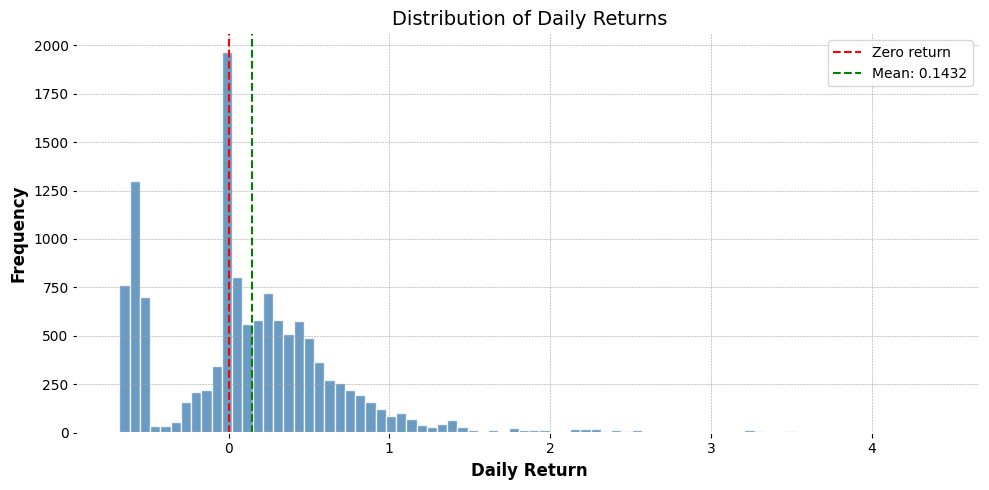

Mean daily return  : 0.1432
Std of returns     : 0.59303
Max single day gain: 4.4173
Max single day loss: -0.6785


In [ ]:
df['daily_return'] = df['close'].pct_change()

plt.figure(figsize=(10, 5))
plt.hist(df['daily_return'].dropna(), bins=80, color='steelblue',
         edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero return')
plt.axvline(df['daily_return'].mean(), color='green', linestyle='--',
            linewidth=1.5, label=f"Mean: {df['daily_return'].mean():.4f}")
plt.title('Distribution of Daily Returns', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('eda_02_returns_dist.png', dpi=150)
plt.show()

print("Mean daily return  :", round(df['daily_return'].mean(), 5))
print("Std of returns     :", round(df['daily_return'].std(), 5))
print("Max single day gain:", round(df['daily_return'].max(), 4))
print("Max single day loss:", round(df['daily_return'].min(), 4))

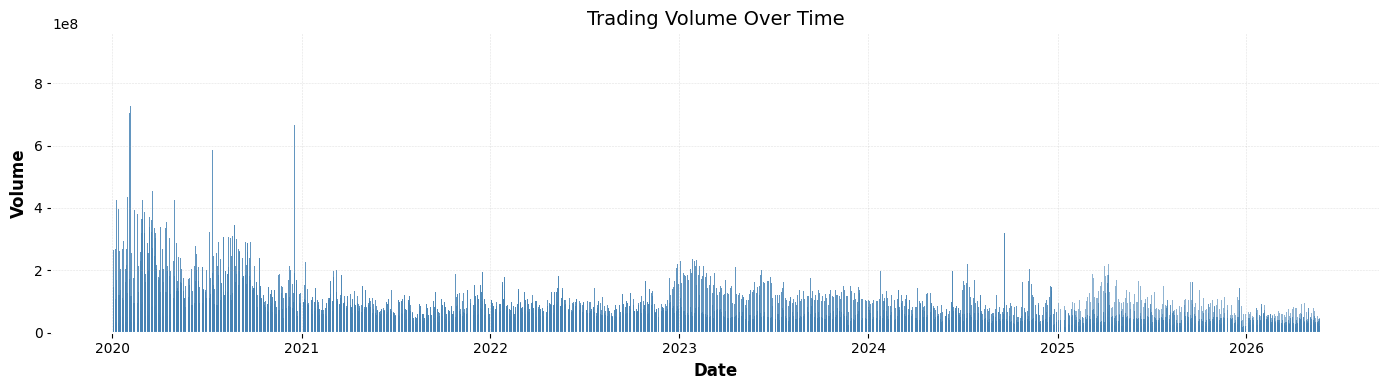

Average daily volume: 68249696
Max daily volume    : 914082000
Min daily volume    : 5855900
Volume std          : 59677304


In [ ]:
plt.figure(figsize=(14, 4))
plt.bar(df['date'], df['volume'], color='steelblue', alpha=0.6, width=1)
plt.title('Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_04_volume.png', dpi=150)
plt.show()

print("Average daily volume:", round(df['volume'].mean()))
print("Max daily volume    :", df['volume'].max())
print("Min daily volume    :", df['volume'].min())
print("Volume std          :", round(df['volume'].std()))

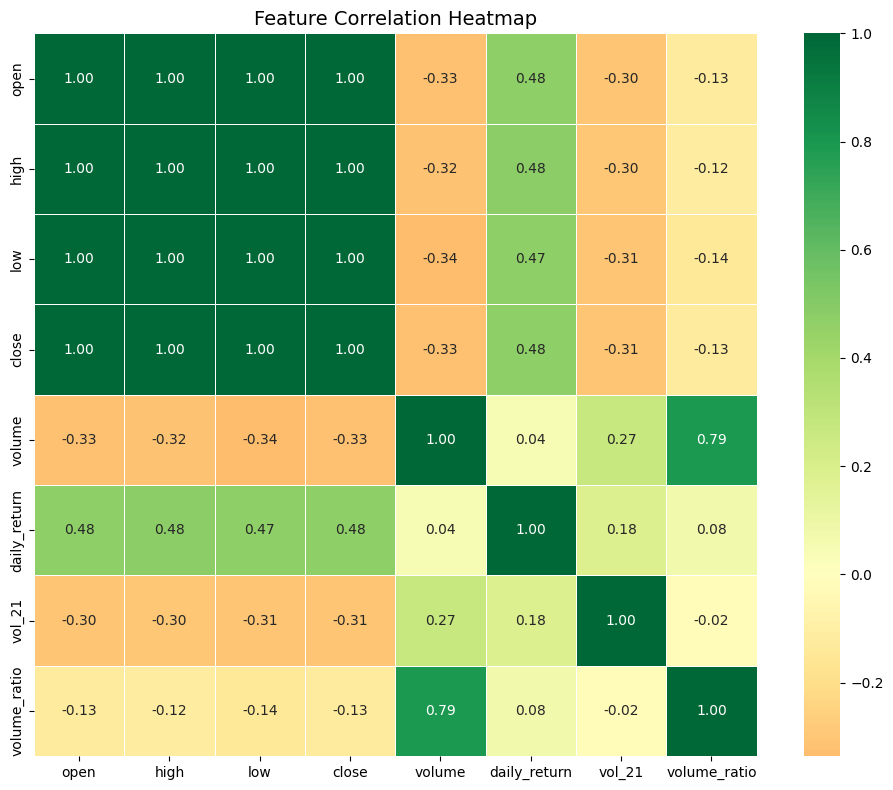

In [ ]:
# add some basic features just for EDA
df['ma_7']  = df['close'].rolling(7).mean()
df['ma_21'] = df['close'].rolling(21).mean()
df['daily_return'] = df['close'].pct_change()
df['vol_21'] = df['daily_return'].rolling(21).std()
df['volume_ratio'] = df['volume'] / df['volume'].rolling(21).mean()

corr_cols = ['open','high','low','close','volume',
             'daily_return','vol_21','volume_ratio']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('eda_05_correlation.png', dpi=150)
plt.show()

<Figure size 1200x500 with 0 Axes>

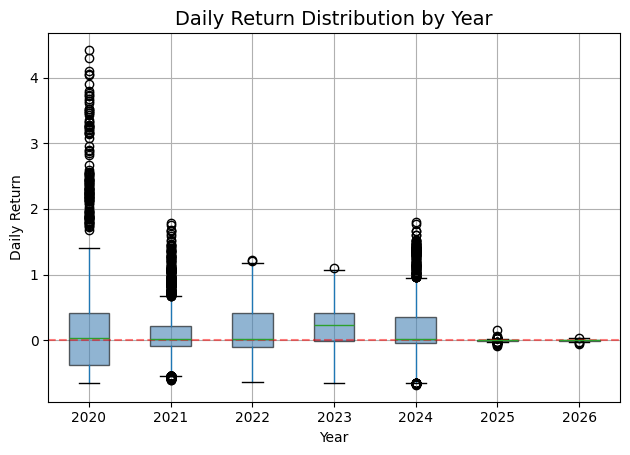

In [ ]:
df['year'] = df['date'].dt.year

plt.figure(figsize=(12, 5))
df.boxplot(column='daily_return', by='year',
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.suptitle('')
plt.title('Daily Return Distribution by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Daily Return')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('eda_06_returns_by_year.png', dpi=150)
plt.show()

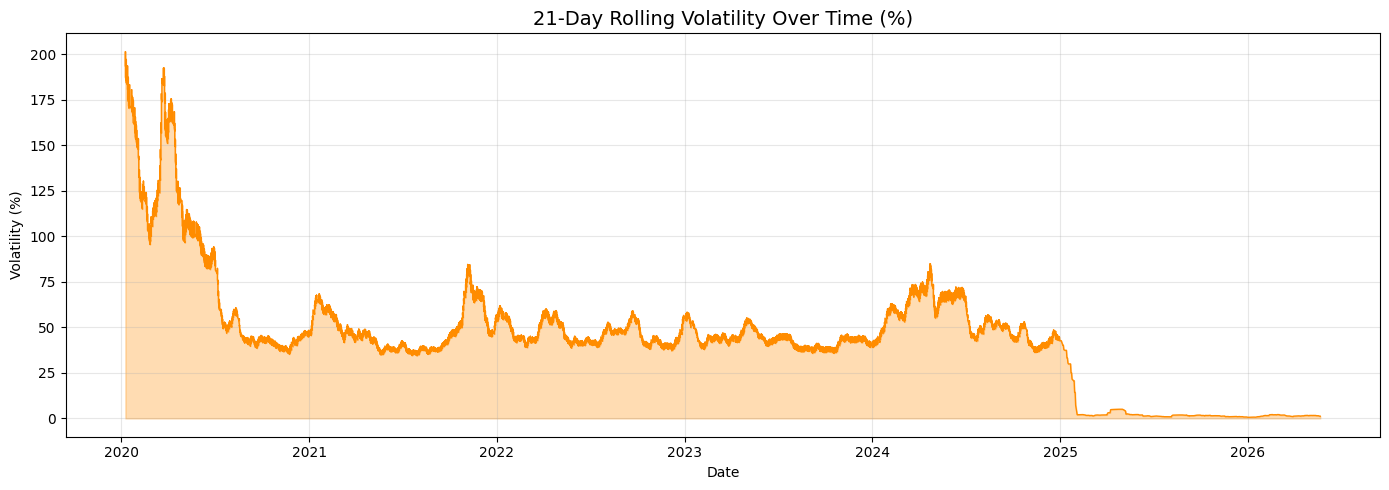

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['vol_21'] * 100,
         color='darkorange', linewidth=1)
plt.fill_between(df['date'], df['vol_21'] * 100,
                 alpha=0.3, color='darkorange')
plt.title('21-Day Rolling Volatility Over Time (%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_07_volatility.png', dpi=150)
plt.show()

Tickers in database: ['AAPL' 'TSLA' 'MSFT' 'GOOGL']

Plotting AAPL — 60 days
From 2026-04-13 to 2026-05-22


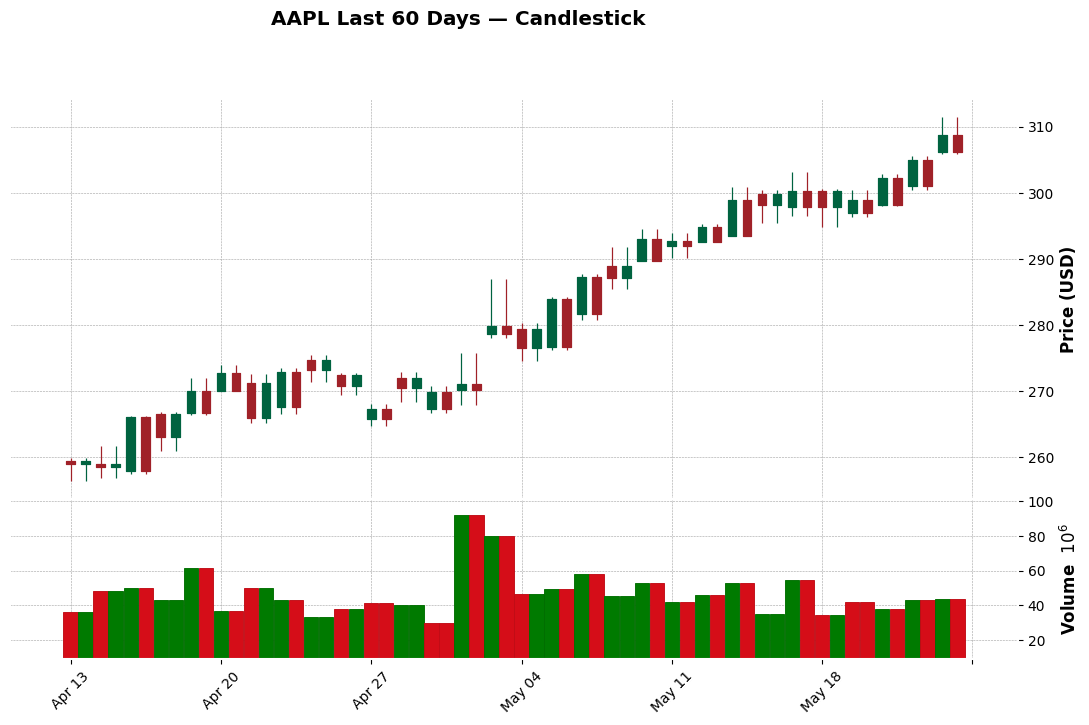


Plotting TSLA — 60 days
From 2026-02-27 to 2026-05-22


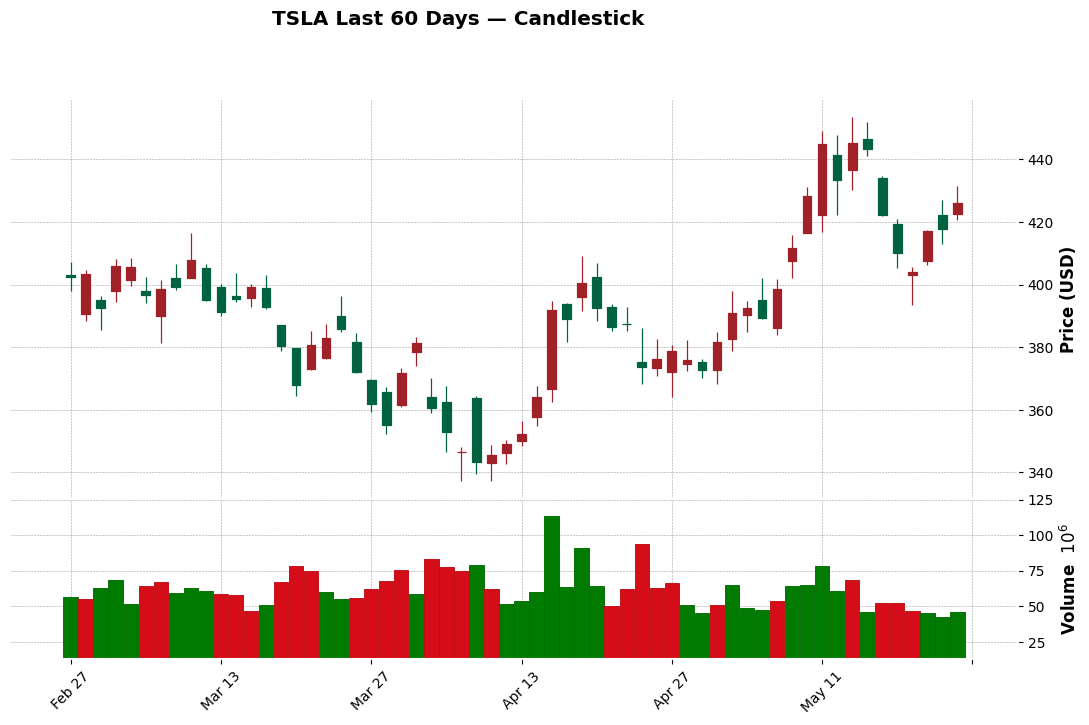


Plotting MSFT — 60 days
From 2026-02-27 to 2026-05-22


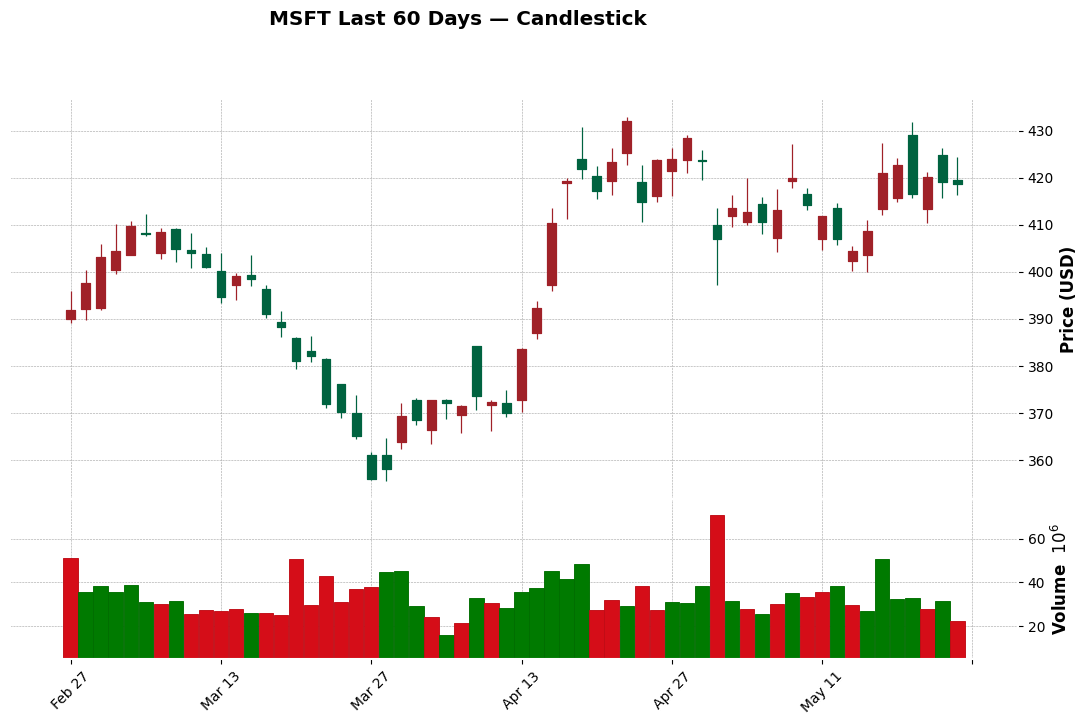

In [72]:
import pandas as pd
import mplfinance as mpf
from sqlalchemy import create_engine

engine = create_engine("sqlite:///stocks.db")

# load all data
df = pd.read_sql("SELECT * FROM raw_prices ORDER BY date", engine)
df['date'] = pd.to_datetime(df['date'])

# see what tickers you have
print("Tickers in database:", df['ticker'].unique())

# ── Function to plot any ticker ───────────────────────────────────
def plot_candle(ticker_name, days=60):
    
    # filter for just that ticker
    ticker_df = df[df['ticker'] == ticker_name].copy()
    
    # set date as index
    ticker_df = ticker_df.set_index('date')
    
    # drop ticker column — mplfinance doesn't want it
    ticker_df = ticker_df.drop(columns=['ticker'])
    
    # capitalize column names
    ticker_df.columns = [col.capitalize() for col in ticker_df.columns]
    
    # force DatetimeIndex
    ticker_df.index = pd.DatetimeIndex(ticker_df.index)
    
    # take last N days
    plot_data = ticker_df.tail(days).copy()
    
    print(f"\nPlotting {ticker_name} — {len(plot_data)} days")
    print(f"From {plot_data.index[0].date()} to {plot_data.index[-1].date()}")
    
    mpf.plot(
        plot_data,
        type='candle',
        style='charles',
        title=f'{ticker_name} Last {days} Days — Candlestick',
        ylabel='Price (USD)',
        volume=True,
        figsize=(14, 8),
        show_nontrading=False
    )

# ── Plot each ticker ──────────────────────────────────────────────
plot_candle('AAPL')
plot_candle('TSLA')
plot_candle('MSFT')

In [ ]:
print("=" * 50)
print("FULL EDA SUMMARY")
print("=" * 50)

print("\nBasic Statistics:")
print(df[['open','high','low','close','volume','daily_return']].describe().round(4))

print("\nTotal trading days  :", len(df))
print("Date range          :", df['date'].min().date(), "to", df['date'].max().date())
print("Positive return days:", (df['daily_return'] > 0).sum())
print("Negative return days:", (df['daily_return'] < 0).sum())
print("Zero return days    :", (df['daily_return'] == 0).sum())

print("\nBiggest single day gains:")
print(df.nlargest(5, 'daily_return')[['date','close','daily_return','volume']])

print("\nBiggest single day crashes:")
print(df.nsmallest(5, 'daily_return')[['date','close','daily_return','volume']])

FULL EDA SUMMARY

Basic Statistics:
            open       high        low      close        volume  daily_return
count  2730.0000  2730.0000  2730.0000  2730.0000  2.730000e+03     2730.0000
mean    166.1878   167.9506   164.4295   166.2083  8.144233e+07        0.0008
std      46.6070    46.9263    46.3326    46.6493  4.512239e+07        0.0187
min      54.1637    55.1607    51.3248    55.0593  1.791060e+07       -0.0925
25%     134.2686   136.2377   132.3323   134.2687  5.101130e+07       -0.0092
50%     162.5452   164.2761   161.1942   162.5452  6.989680e+07        0.0005
75%     191.0114   192.5258   189.7178   191.0431  9.682040e+07        0.0104
max     299.8200   303.2000   296.5200   300.2300  4.016932e+08        0.1533

Total trading days  : 2730
Date range          : 2020-03-13 to 2026-05-15
Positive return days: 1397
Negative return days: 1332
Zero return days    : 1

Biggest single day gains:
           date       close  daily_return     volume
2502 2025-04-09  197.804855  

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# connect to your database
engine = create_engine("sqlite:///stocks.db")

# read raw prices from SQL into a DataFrame
df = pd.read_sql("SELECT * FROM raw_prices WHERE ticker = 'AAPL' ORDER BY date", engine)

# always sort by date — very important for time series
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# ── FEATURE 1: Daily Return ──────────────────────────────────────
df['daily_return'] = df['close'].pct_change()

# ── FEATURE 2: Moving Averages ───────────────────────────────────
df['ma_7']  = df['close'].rolling(window=7).mean()
df['ma_21'] = df['close'].rolling(window=21).mean()
df['ma_50'] = df['close'].rolling(window=50).mean()
# Price distance from moving average — how far above or below trend
df['price_vs_ma21'] = (df['close'] - df['ma_21']) / df['ma_21']
df['price_vs_ma50'] = (df['close'] - df['ma_50']) / df['ma_50']

# Momentum — is price accelerating or decelerating
df['momentum_5']  = df['close'] / df['close'].shift(5) - 1
df['momentum_10'] = df['close'] / df['close'].shift(10) - 1

# RSI slope — is RSI rising or falling
df['rsi_slope'] = df['rsi'] - df['rsi'].shift(3)

# ── FEATURE 3: MA Crossover Signal ───────────────────────────────
df['ma_cross'] = (df['ma_7'] > df['ma_21']).astype(int)

# ── FEATURE 4: Volatility ─────────────────────────────────────────
df['volatility'] = df['daily_return'].rolling(window=21).std()

# ── FEATURE 5: RSI ────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0)
    loss  = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi'] = compute_rsi(df['close'])

# ── FEATURE 6: MACD ───────────────────────────────────────────────
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd']        = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# ── FEATURE 7: Bollinger Bands ────────────────────────────────────
df['bb_mid']   = df['close'].rolling(window=20).mean()
df['bb_upper'] = df['bb_mid'] + 2 * df['close'].rolling(window=20).std()
df['bb_lower'] = df['bb_mid'] - 2 * df['close'].rolling(window=20).std()
df['bb_width'] = df['bb_upper'] - df['bb_lower']
df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# ── FEATURE 8: Volume Features ────────────────────────────────────
df['volume_ma']    = df['volume'].rolling(window=21).mean()
df['volume_ratio'] = df['volume'] / df['volume_ma']

# ── FEATURE 9: Lag Features ───────────────────────────────────────
df['close_lag1'] = df['close'].shift(1)
df['close_lag3'] = df['close'].shift(3)
df['close_lag5'] = df['close'].shift(5)
df['return_lag1'] = df['daily_return'].shift(1)
df['return_lag3'] = df['daily_return'].shift(3)

# ── TARGET VARIABLE: What we want to predict ─────────────────────
df['future_return'] = df['close'].shift(-5) / df['close'] - 1

def label_signal(x):
    if x > 0.03:       # price goes up more than 2% in 5 days → BUY
        return 1
    elif x < -0.03:    # price drops more than 2% in 5 days → SELL
        return -1
    else:
        return 0       # stays flat → HOLD

df['signal'] = df['future_return'].apply(label_signal)

# ── CLEANUP ───────────────────────────────────────────────────────
df = df.dropna()

# ── SAVE TO SQL ───────────────────────────────────────────────────
df.to_sql("features", con=engine, if_exists="replace", index=False)

print("Feature engineering done!")
print("Shape:", df.shape)
print("\nSignal distribution:")
print(df['signal'].value_counts())
print("\nSample of features:")
print(df[['date','close','rsi','macd','bb_position','signal']].tail(10))

Feature engineering done!
Shape: (2730, 31)

Signal distribution:
signal
 0    2018
 1     403
-1     309
Name: count, dtype: int64

Sample of features:
           date       close        rsi      macd  bb_position  signal
2769 2026-05-04  276.575165  65.745273  4.555137     0.842368       1
2770 2026-05-05  283.918427  65.594804  5.244063     1.036124       1
2771 2026-05-06  287.245361  71.071507  5.989454     1.046127       1
2772 2026-05-07  287.175415  67.056485  6.499615     0.969757       1
2773 2026-05-08  293.050018  68.940400  7.293873     1.039195       0
2774 2026-05-11  292.679993  78.488691  7.803516     0.965198       0
2775 2026-05-12  294.799988  75.997537  8.282996     0.962562       0
2776 2026-05-13  298.869995  77.990306  8.888938     0.981569       0
2777 2026-05-14  298.209991  81.004690  9.209730     0.914522       0
2778 2026-05-15  300.230011  88.431878  9.517249     0.903064       0


In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

engine = create_engine("sqlite:///stocks.db")
df = pd.read_sql("SELECT * FROM features ORDER BY date", engine)
df['date'] = pd.to_datetime(df['date'])

print("Signal distribution:")
print(df['signal'].value_counts())
print(df['signal'].value_counts(normalize=True).round(3))

# ── Features ──────────────────────────────────────────────────────
feature_cols = [
    'daily_return',
    'ma_7', 'ma_21', 'ma_50',
    'ma_cross',
    'volatility',
    'rsi',
    'macd', 'macd_signal', 'macd_hist',
    'bb_position', 'bb_width',
    'volume_ratio',
    'close_lag1', 'close_lag3', 'close_lag5',
    'return_lag1', 'return_lag3',
    'price_vs_ma21', 'price_vs_ma50',
    'momentum_5', 'momentum_10',
    'rsi_slope'
]

# keep only columns that exist in your table
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['signal']

# ── Time-based split ──────────────────────────────────────────────
train_mask = df['date'] < '2023-01-01'
test_mask  = df['date'] >= '2023-01-01'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# ── Scale ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── SMOTE — fix class imbalance ───────────────────────────────────
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_bal).value_counts())

# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test_scaled)

print("\n── Random Forest ──────────────────────────────")
print("Accuracy:RANDOM", round(accuracy_score(y_test, rf_preds) * 100, 2), "%")
print(classification_report(y_test, rf_preds, target_names=['SELL','HOLD','BUY']))

# ── XGBoost ───────────────────────────────────────────────────────
y_train_xgb = pd.Series(y_train_bal).map({-1:0, 0:1, 1:2})
y_test_xgb  = y_test.map({-1:0, 0:1, 1:2})

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_bal, y_train_xgb)
xgb_raw   = xgb_model.predict(X_test_scaled)
xgb_preds = pd.Series(xgb_raw).map({0:-1, 1:0, 2:1}).values

print("\n── XGBoost ────────────────────────────────────")
print("Accuracy: XGBOOST", round(accuracy_score(y_test, xgb_preds) * 100, 2), "%")
print(classification_report(y_test, xgb_preds, target_names=['SELL','HOLD','BUY']))

# ── Feature Importance ────────────────────────────────────────────
print("\n── Top 10 Most Important Features ────────────")
imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(imp.head(10).to_string(index=False))

# ── Save predictions ──────────────────────────────────────────────
results = df[test_mask][['date','ticker','close','signal']].copy()
results['rf_prediction']  = rf_preds
results['xgb_prediction'] = xgb_preds
results['rf_correct']     = (results['rf_prediction']  == results['signal']).astype(int)
results['xgb_correct']    = (results['xgb_prediction'] == results['signal']).astype(int)
results.to_sql("predictions", con=engine, if_exists="replace", index=False)

print("\nSaved predictions to SQL!")

# ── TODAY'S PREDICTION ────────────────────────────────────────────
print("\n" + "="*50)
print("TODAY'S SIGNAL PREDICTION")
print("="*50)

latest = df[feature_cols].iloc[-1:]
latest_scaled = scaler.transform(latest)

rf_today  = rf.predict(latest_scaled)[0]
xgb_today_raw = xgb_model.predict(latest_scaled)[0]
xgb_today = {0:-1, 1:0, 2:1}[xgb_today_raw]

rf_proba  = rf.predict_proba(latest_scaled)[0]
xgb_proba = xgb_model.predict_proba(latest_scaled)[0]

label_map = {1: "BUY  ✓", 0: "HOLD —", -1: "SELL  ✗"}

print(f"\nDate of latest data : {df['date'].iloc[-1].date()}")
print(f"Latest close price  : ${df['close'].iloc[-1]:.2f}")
print(f"\nRandom Forest says  : {label_map[rf_today]}")
print(f"  Confidence — SELL: {rf_proba[0]*100:.1f}%  HOLD: {rf_proba[1]*100:.1f}%  BUY: {rf_proba[2]*100:.1f}%")
print(f"\nXGBoost says        : {label_map[xgb_today]}")
print(f"  Confidence — SELL: {xgb_proba[0]*100:.1f}%  HOLD: {xgb_proba[1]*100:.1f}%  BUY: {xgb_proba[2]*100:.1f}%")

if rf_today == xgb_today:
    print(f"\n✓ Both models AGREE — strong signal: {label_map[rf_today]}")
else:
    print(f"\n⚠ Models DISAGREE — be cautious, wait for clearer signal")

Signal distribution:
signal
 0    2018
 1     403
-1     309
Name: count, dtype: int64
signal
 0    0.739
 1    0.148
-1    0.113
Name: proportion, dtype: float64

After SMOTE:
signal
-1    977
 1    977
 0    977
Name: count, dtype: int64

── Random Forest ──────────────────────────────
Accuracy:RANDOM 43.46 %
              precision    recall  f1-score   support

        SELL       0.08      0.40      0.14       124
        HOLD       0.75      0.50      0.60      1041
         BUY       0.28      0.07      0.11       181

    accuracy                           0.43      1346
   macro avg       0.37      0.33      0.28      1346
weighted avg       0.62      0.43      0.49      1346


── XGBoost ────────────────────────────────────
Accuracy: XGBOOST 49.11 %
              precision    recall  f1-score   support

        SELL       0.07      0.27      0.11       124
        HOLD       0.74      0.60      0.66      1041
         BUY       0.22      0.04      0.07       181

    accuracy 

In [73]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

engine = create_engine("sqlite:///stocks.db")

# ── Load data ─────────────────────────────────────────────────────
df = pd.read_sql("SELECT * FROM features ORDER BY date", engine)
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded {len(df)} rows of feature data")

# ── Features to mine ──────────────────────────────────────────────
mine_cols = [
    'daily_return', 'volatility',
    'rsi', 'macd', 'macd_hist',
    'bb_position', 'bb_width',
    'volume_ratio', 'ma_cross'
]

X = df[mine_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ════════════════════════════════════════════════════════════
# PART 1 — K-MEANS CLUSTERING
# ════════════════════════════════════════════════════════════

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# get mean values per cluster to understand and name them
cluster_means = df.groupby('cluster')[mine_cols].mean()

# automatically name each cluster based on its characteristics
def name_cluster(row):
    if row['daily_return'] > 0.001 and row['rsi'] > 55 and row['macd'] > 0:
        return 'Bull Momentum'
    elif row['daily_return'] < -0.001 and row['rsi'] < 45 and row['macd'] < 0:
        return 'Bear Pressure'
    elif row['volatility'] > row['volatility'] * 1.2 and abs(row['macd_hist']) > 0.5:
        return 'Volatile Confusion'
    else:
        return 'Sideways Calm'

cluster_name_map = {}
for cluster_id, row in cluster_means.iterrows():
    cluster_name_map[cluster_id] = name_cluster(row)

df['regime'] = df['cluster'].map(cluster_name_map)

# regime advice dictionary
regime_advice = {
    'Bull Momentum': {
        'meaning' : 'Stock is in a strong uptrend. RSI healthy, MACD positive, returns positive.',
        'advice'  : 'Good time to BUY or HOLD existing positions. Trend is your friend.',
        'risk'    : 'Low — momentum is supporting price.',
        'emoji'   : '📈'
    },
    'Bear Pressure': {
        'meaning' : 'Stock is under selling pressure. RSI weak, MACD negative, returns negative.',
        'advice'  : 'Avoid new BUY positions. Consider reducing exposure or waiting.',
        'risk'    : 'High — downward pressure is active.',
        'emoji'   : '📉'
    },
    'Sideways Calm': {
        'meaning' : 'Stock is moving sideways with low volatility. No clear direction.',
        'advice'  : 'HOLD if you own it. Wait for a breakout before buying more.',
        'risk'    : 'Medium — no trend means uncertainty.',
        'emoji'   : '➡️'
    },
    'Volatile Confusion': {
        'meaning' : 'High volatility with no clear direction. Mixed signals everywhere.',
        'advice'  : 'Be very cautious. Reduce position size. Wait for clarity.',
        'risk'    : 'Very High — unpredictable swings likely.',
        'emoji'   : '⚠️'
    }
}


# ════════════════════════════════════════════════════════════
# PART 2 — ISOLATION FOREST (Anomaly Detection)
# ════════════════════════════════════════════════════════════

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df['anomaly_score'] = iso.fit_predict(X_scaled)
df['anomaly_flag']  = (df['anomaly_score'] == -1).astype(int)


# ════════════════════════════════════════════════════════════
# PART 3 — DBSCAN (Structural Outliers)
# ════════════════════════════════════════════════════════════

dbscan = DBSCAN(eps=1.5, min_samples=10)
df['dbscan_label'] = dbscan.fit_predict(X_scaled)
df['dbscan_outlier'] = (df['dbscan_label'] == -1).astype(int)


# ════════════════════════════════════════════════════════════
# PART 4 — ASSOCIATION RULES
# ════════════════════════════════════════════════════════════

rules_df = pd.DataFrame()
rules_df['rsi_oversold']     = (df['rsi'] < 35).astype(bool)
rules_df['rsi_overbought']   = (df['rsi'] > 65).astype(bool)
rules_df['rsi_neutral']      = ((df['rsi'] >= 35) & (df['rsi'] <= 65)).astype(bool)
rules_df['macd_bullish']     = (df['macd'] > df['macd_signal']).astype(bool)
rules_df['macd_bearish']     = (df['macd'] < df['macd_signal']).astype(bool)
rules_df['vol_spike']        = (df['volume_ratio'] > 1.5).astype(bool)
rules_df['vol_low']          = (df['volume_ratio'] < 0.7).astype(bool)
rules_df['price_upper_band'] = (df['bb_position'] > 0.8).astype(bool)
rules_df['price_lower_band'] = (df['bb_position'] < 0.2).astype(bool)
rules_df['uptrend']          = (df['ma_cross'] == 1).astype(bool)
rules_df['high_volatility']  = (df['volatility'] > df['volatility'].quantile(0.75)).astype(bool)
rules_df['signal_buy']       = (df['signal'] == 1).astype(bool)
rules_df['signal_sell']      = (df['signal'] == -1).astype(bool)
rules_df['signal_hold']      = (df['signal'] == 0).astype(bool)

frequent_items = apriori(rules_df, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

buy_rules  = rules[rules['consequents'].astype(str).str.contains('signal_buy')].head(5)
sell_rules = rules[rules['consequents'].astype(str).str.contains('signal_sell')].head(5)


# ════════════════════════════════════════════════════════════
# PART 5 — PCA
# ════════════════════════════════════════════════════════════

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]


# ════════════════════════════════════════════════════════════
# SAVE TO SQL
# ════════════════════════════════════════════════════════════

save_cols = [
    'date', 'ticker', 'close', 'daily_return',
    'rsi', 'macd', 'bb_position', 'volume_ratio',
    'signal', 'cluster', 'regime', 'anomaly_flag',
    'dbscan_outlier', 'pca_x', 'pca_y'
]
df[save_cols].to_sql("mining_results", con=engine, if_exists="replace", index=False)


# ════════════════════════════════════════════════════════════
# THE HUMAN READABLE REPORT — THIS IS THE MAIN OUTPUT
# ════════════════════════════════════════════════════════════

# get today's (latest) row
today = df.iloc[-1]
today_date  = today['date'].date()
today_close = today['close']
today_rsi   = round(today['rsi'], 1)
today_macd  = round(today['macd'], 4)
today_bb    = round(today['bb_position'], 2)
today_vol   = round(today['volume_ratio'], 2)
today_ret   = round(today['daily_return'] * 100, 2)
today_regime  = today['regime']
today_anomaly = today['anomaly_flag']
today_dbscan  = today['dbscan_outlier']

print("\n")
print("═" * 58)
print("   MARKET ANALYSIS REPORT —", df['ticker'].iloc[-1])
print("   Date  :", today_date)
print("   Price : $" + str(round(today_close, 2)))
print("═" * 58)


# ── Section 1: What happened today ───────────────────────────────
print("\n📊 TODAY'S PRICE BEHAVIOUR")
print("─" * 40)
print(f"  Close Price    : ${round(today_close, 2)}")
print(f"  Daily Return   : {today_ret}%", end="  ")
if today_ret > 1:
    print("→ Strong up day")
elif today_ret > 0:
    print("→ Slightly up")
elif today_ret < -1:
    print("→ Strong down day")
else:
    print("→ Slightly down")

print(f"  Volume Ratio   : {today_vol}x normal", end="  ")
if today_vol > 2:
    print("→ Very high volume — something significant happened")
elif today_vol > 1.3:
    print("→ Above average volume — confirms price move")
elif today_vol < 0.7:
    print("→ Low volume — weak conviction in price move")
else:
    print("→ Normal volume")


# ── Section 2: Indicator readings ────────────────────────────────
print("\n📉 TECHNICAL INDICATOR READINGS")
print("─" * 40)

print(f"  RSI  : {today_rsi}", end="  →  ")
if today_rsi > 70:
    print("OVERBOUGHT — stock has risen too fast. Pullback likely.")
elif today_rsi > 60:
    print("Strong zone — bullish momentum but watch for exhaustion.")
elif today_rsi < 30:
    print("OVERSOLD — stock has fallen too hard. Bounce likely.")
elif today_rsi < 40:
    print("Weak zone — bearish momentum. Avoid buying yet.")
else:
    print("Neutral zone (40–60) — no strong signal from RSI.")

print(f"  MACD : {today_macd}", end="  →  ")
if today_macd > 0 and today['macd_hist'] > 0:
    print("Bullish — short term momentum stronger than long term.")
elif today_macd > 0 and today['macd_hist'] < 0:
    print("Bullish but momentum is fading. Watch closely.")
elif today_macd < 0 and today['macd_hist'] < 0:
    print("Bearish — selling pressure is accelerating.")
else:
    print("Bearish but pressure is easing. Possible reversal forming.")

print(f"  BB Position : {today_bb}", end="  →  ")
if today_bb > 0.85:
    print("Price near UPPER band — overbought in recent range.")
elif today_bb > 0.6:
    print("Price in upper half — mild bullish bias.")
elif today_bb < 0.15:
    print("Price near LOWER band — oversold in recent range.")
elif today_bb < 0.4:
    print("Price in lower half — mild bearish bias.")
else:
    print("Price near middle — no extreme reading.")


# ── Section 3: Market Regime ──────────────────────────────────────
print("\n🏛️  MARKET REGIME ANALYSIS")
print("─" * 40)
advice = regime_advice.get(today_regime, regime_advice['Sideways Calm'])
print(f"  Current Regime : {advice['emoji']}  {today_regime}")
print(f"  What it means  : {advice['meaning']}")
print(f"  What to do     : {advice['advice']}")
print(f"  Risk level     : {advice['risk']}")

# show how long we have been in this regime
regime_streak = 0
for i in range(len(df)-1, -1, -1):
    if df.iloc[i]['regime'] == today_regime:
        regime_streak += 1
    else:
        break
print(f"  Days in regime : {regime_streak} consecutive days")
if regime_streak > 10:
    print("                   Long streak — regime is well established.")
elif regime_streak > 5:
    print("                   Moderate streak — regime is holding.")
else:
    print("                   Short streak — regime may still be forming.")


# ── Section 4: Anomaly Check ──────────────────────────────────────
print("\n🔍 ANOMALY DETECTION")
print("─" * 40)

if today_anomaly == 1 or today_dbscan == 1:
    print("  ⚠️  WARNING — TODAY IS AN ANOMALY DAY")
    print("  This day's price/volume behaviour is statistically unusual.")
    print("  Do NOT rely on model signals today.")
    print("  Possible reasons: earnings release, Fed news, macro event.")
    print("  Recommended action: HOLD. Do not make new trades today.")
else:
    print("  ✓  Today is a NORMAL day — no anomaly detected.")
    print("  Price and volume behaviour is within expected range.")
    print("  Model signals are reliable today.")

# show recent anomaly days
recent_anomalies = df[df['anomaly_flag'] == 1].tail(5)
if len(recent_anomalies) > 0:
    print(f"\n  Last {len(recent_anomalies)} anomaly days in your data:")
    for _, row in recent_anomalies.iterrows():
        direction = "UP" if row['daily_return'] > 0 else "DOWN"
        print(f"    {row['date'].date()}  |  "
              f"Return: {round(row['daily_return']*100,2)}% {direction}  |  "
              f"Volume: {round(row['volume_ratio'],1)}x normal")


# ── Section 5: Association Rules ─────────────────────────────────
print("\n🔗 HIDDEN PATTERN ANALYSIS (Association Rules)")
print("─" * 40)

# check today's conditions against each rule
print("  Checking today's indicators against mined rules...\n")

def check_antecedents(antecedent_set, today_row):
    today_conditions = {
        'rsi_oversold'     : today_row['rsi'] < 35,
        'rsi_overbought'   : today_row['rsi'] > 65,
        'rsi_neutral'      : 35 <= today_row['rsi'] <= 65,
        'macd_bullish'     : today_row['macd'] > today_row['macd_signal'],
        'macd_bearish'     : today_row['macd'] < today_row['macd_signal'],
        'vol_spike'        : today_row['volume_ratio'] > 1.5,
        'vol_low'          : today_row['volume_ratio'] < 0.7,
        'price_upper_band' : today_row['bb_position'] > 0.8,
        'price_lower_band' : today_row['bb_position'] < 0.2,
        'uptrend'          : today_row['ma_cross'] == 1,
        'high_volatility'  : today_row['volatility'] > df['volatility'].quantile(0.75),
    }
    matched = []
    not_matched = []
    for cond in antecedent_set:
        if cond in today_conditions:
            if today_conditions[cond]:
                matched.append(cond)
            else:
                not_matched.append(cond)
    return matched, not_matched

# print BUY rules
print("  TOP BUY PATTERNS FOUND IN HISTORICAL DATA:")
if len(buy_rules) == 0:
    print("  No strong BUY rules found in data.")
else:
    for i, (_, rule) in enumerate(buy_rules.iterrows()):
        conditions  = list(rule['antecedents'])
        confidence  = round(rule['confidence'] * 100, 1)
        lift        = round(rule['lift'], 2)
        matched, not_matched = check_antecedents(rule['antecedents'], today)
        active = len(not_matched) == 0

        print(f"\n  BUY Rule {i+1}:")
        print(f"    When  : {' + '.join(conditions)}")
        print(f"    Then  : BUY signal follows {confidence}% of the time")
        print(f"    Lift  : {lift}x better than random guessing")
        if active:
            print(f"    TODAY : ✅ ALL CONDITIONS MET — This BUY pattern is ACTIVE today!")
        else:
            matched_str     = ', '.join(matched) if matched else 'none'
            not_matched_str = ', '.join(not_matched)
            print(f"    TODAY : ❌ Rule NOT active.")
            print(f"            Met     : {matched_str}")
            print(f"            Missing : {not_matched_str}")

# print SELL rules
print("\n  TOP SELL PATTERNS FOUND IN HISTORICAL DATA:")
if len(sell_rules) == 0:
    print("  No strong SELL rules found in data.")
else:
    for i, (_, rule) in enumerate(sell_rules.iterrows()):
        conditions  = list(rule['antecedents'])
        confidence  = round(rule['confidence'] * 100, 1)
        lift        = round(rule['lift'], 2)
        matched, not_matched = check_antecedents(rule['antecedents'], today)
        active = len(not_matched) == 0

        print(f"\n  SELL Rule {i+1}:")
        print(f"    When  : {' + '.join(conditions)}")
        print(f"    Then  : SELL signal follows {confidence}% of the time")
        print(f"    Lift  : {lift}x better than random guessing")
        if active:
            print(f"    TODAY : ✅ ALL CONDITIONS MET — This SELL pattern is ACTIVE today!")
        else:
            matched_str     = ', '.join(matched) if matched else 'none'
            not_matched_str = ', '.join(not_matched)
            print(f"    TODAY : ❌ Rule NOT active.")
            print(f"            Met     : {matched_str}")
            print(f"            Missing : {not_matched_str}")


# ── Section 6: Final Summary ──────────────────────────────────────
print("\n")
print("═" * 58)
print("   FINAL SUMMARY")
print("═" * 58)

# collect signals
signals = []
if today_rsi < 35:
    signals.append(("BUY",  "RSI oversold"))
if today_rsi > 70:
    signals.append(("SELL", "RSI overbought"))
if today_macd > 0 and today['macd_hist'] > 0:
    signals.append(("BUY",  "MACD bullish crossover"))
if today_macd < 0 and today['macd_hist'] < 0:
    signals.append(("SELL", "MACD bearish momentum"))
if today_bb < 0.15:
    signals.append(("BUY",  "Price at lower Bollinger Band"))
if today_bb > 0.85:
    signals.append(("SELL", "Price at upper Bollinger Band"))
if today_regime == 'Bull Momentum':
    signals.append(("BUY",  "Market in Bull Momentum regime"))
if today_regime == 'Bear Pressure':
    signals.append(("SELL", "Market in Bear Pressure regime"))

buy_count  = sum(1 for s in signals if s[0] == "BUY")
sell_count = sum(1 for s in signals if s[0] == "SELL")

print(f"\n  Signals in favour of BUY  : {buy_count}")
for s in signals:
    if s[0] == "BUY":
        print(f"    ✅ {s[1]}")

print(f"\n  Signals in favour of SELL : {sell_count}")
for s in signals:
    if s[0] == "SELL":
        print(f"    🔴 {s[1]}")

print()
if today_anomaly == 1:
    print("  ⚠️  FINAL VERDICT : HOLD — Anomaly day. Do not trade.")
elif buy_count > sell_count and buy_count >= 2:
    print("  ✅  FINAL VERDICT : BUY — Multiple indicators agree.")
    print("      Confidence    : Multiple independent signals confirming.")
elif sell_count > buy_count and sell_count >= 2:
    print("  🔴  FINAL VERDICT : SELL — Multiple indicators agree.")
    print("      Confidence    : Multiple independent signals confirming.")
elif buy_count == sell_count:
    print("  ➡️   FINAL VERDICT : HOLD — Signals are mixed. No clear direction.")
    print("      Wait for a clearer setup before entering a trade.")
else:
    print("  ➡️   FINAL VERDICT : HOLD — Not enough signals to act.")
    print("      Only one indicator is pointing in a direction. Wait.")

print()
print("  NOTE: This is a learning project. Never trade real money")
print("        based solely on a model's output.")
print("═" * 58)

Loaded 2730 rows of feature data


══════════════════════════════════════════════════════════
   MARKET ANALYSIS REPORT — AAPL
   Date  : 2026-05-15
   Price : $300.23
══════════════════════════════════════════════════════════

📊 TODAY'S PRICE BEHAVIOUR
────────────────────────────────────────
  Close Price    : $300.23
  Daily Return   : 0.68%  → Slightly up
  Volume Ratio   : 1.12x normal  → Normal volume

📉 TECHNICAL INDICATOR READINGS
────────────────────────────────────────
  RSI  : 88.4  →  OVERBOUGHT — stock has risen too fast. Pullback likely.
  MACD : 9.5172  →  Bullish — short term momentum stronger than long term.
  BB Position : 0.9  →  Price near UPPER band — overbought in recent range.

🏛️  MARKET REGIME ANALYSIS
────────────────────────────────────────
  Current Regime : 📈  Bull Momentum
  What it means  : Stock is in a strong uptrend. RSI healthy, MACD positive, returns positive.
  What to do     : Good time to BUY or HOLD existing positions. Trend is your friend.
  Ris